### Architecture 
here the FiLM applied to mid stage with the frozen backbone ?

<br>
<br>

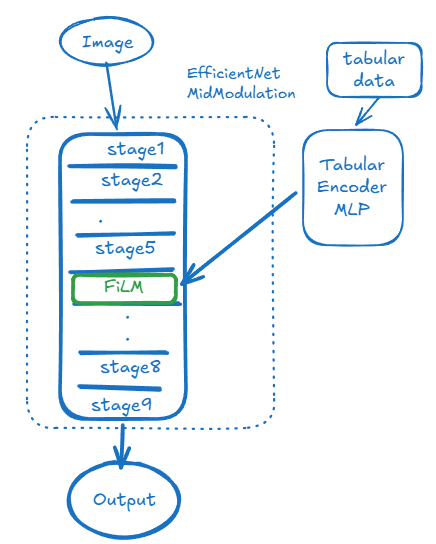



In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.insert(0, os.path.abspath("../../.."))

In [3]:
# Cell 1: imports & setup
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gc

gc.enable()

import torch


from src.config import EXP_CONFIGS
from src.utils import set_seed, save_config




main_folder = "../../.."
data_csv = os.path.join(main_folder, "data", "train.csv")
img_folder = os.path.join(main_folder, "data", "train")
out_dir = os.path.join(main_folder, "outputs","extra", "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_identity_init")

df = pd.read_csv(data_csv)
cfg = EXP_CONFIGS["exp12_film"]   # define in config
cfg["name"] = "exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_identity_init"

TARGET = "Pawpularity"
tab_cols = [c for c in df.columns if c not in ["Id", TARGET]]

os.makedirs(out_dir, exist_ok=True)
save_config(cfg, out_dir)
set_seed(cfg["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [4]:
from sklearn.model_selection import KFold
from sklearn.metrics import root_mean_squared_error
from src.train import run_single_fold

kf = KFold(n_splits=cfg["n_splits"], shuffle=True, random_state=cfg["seed"])
oof_pred = np.zeros(len(df))
oof_true = df[TARGET].values
fold_index = np.full(len(df), -1, dtype=int)
fold_rmse = []

start_all = time.time()
for fold, (tr_idx, val_idx) in enumerate(kf.split(df), start=1):
    print(f"\n=== {cfg['name']}: Fold {fold} ===")
    train_df = df.iloc[tr_idx].reset_index(drop=True)
    val_df   = df.iloc[val_idx].reset_index(drop=True)

    best_rmse, val_preds, val_targets, val_ids = run_single_fold(
    fold=fold,
    train_df=train_df,
    val_df=val_df,
    img_folder=img_folder,
    cfg=cfg,
    out_dir=out_dir,
    device=device,
    mode="film_fusion",   
    tab_cols=tab_cols,
    workers=16,
    pin_memory=True,
    persistent_workers=True,
    ##film related parameter
    film_start_idx=3,                   # to update the backbone block at early stage on index 0 (1st block of EfficientNet)
    apply_to_all_after=False,            # True: apply FiLM toall blocks >= idx, False: only at idx, so here we only apply FiLM at 1st stage/block of EfficientNet
    use_bn_affine=False,                # False => BN used but only normalizes values and doest not apply affine transformation(gamma & beta), instead FiLM applies affine transformation
    freeze_backbone=True,              # False => finetune EfficientNet-B1,True -> Freezen backbone entirely
    identity_init=True
)

    oof_pred[val_idx] = val_preds
    fold_index[val_idx] = fold
    fold_rmse.append(best_rmse)
    print(f"Fold {fold} best RMSE: {best_rmse:.4f}")

all_sec = time.time() - start_all
print(f"\nTotal training time: {int(all_sec//60)}m {int(all_sec%60)}s")
# final metrics + OOF with fold column
oof_rmse = root_mean_squared_error(oof_true, oof_pred)
fold_rmse = np.array(fold_rmse)
print(f"\nOOF RMSE: {oof_rmse:.4f}")
print(f"Fold RMSEs: {fold_rmse.tolist()}  Mean={fold_rmse.mean():.4f}  Std={fold_rmse.std():.4f}")

oof_df = pd.DataFrame({
    "Id": df["Id"],
    "fold": fold_index,     
    "ytrue": oof_true,
    "oof_pred": oof_pred,
})
oof_df["abs_err"] = (oof_df["ytrue"] - oof_df["oof_pred"]).abs()
oof_df.to_csv(os.path.join(out_dir, "oof_detail.csv"), index=False)
oof_df.sort_values("abs_err", ascending=False).head(50).to_csv(
    os.path.join(out_dir, "top50_errors.csv"), index=False
)

np.save(os.path.join(out_dir, "oof_pred.npy"), oof_pred)
np.save(os.path.join(out_dir, "fold_rmse.npy"), fold_rmse)
with open(os.path.join(out_dir, "metrics.txt"), "w") as f:
    f.write(f"OOF_RMSE: {oof_rmse:.4f}\n")
    f.write(f"Fold_RMSE: {fold_rmse.tolist()}\nMean: {fold_rmse.mean():.4f}\nStd: {fold_rmse.std():.4f}\n")


/home/ghias/miniconda3/envs/rapids-env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_identity_init: Fold 1 ===
Epoch 1/10 | Fold 1 | Train[MSE]: RMSE=40.7665 | ValRMSE: 38.4021
Epoch 2/10 | Fold 1 | Train[MSE]: RMSE=34.9703 | ValRMSE: 33.1009
Epoch 3/10 | Fold 1 | Train[MSE]: RMSE=29.7090 | ValRMSE: 28.7693
Epoch 4/10 | Fold 1 | Train[MSE]: RMSE=26.6798 | ValRMSE: 26.9535
Epoch 5/10 | Fold 1 | Train[MSE]: RMSE=25.4362 | ValRMSE: 26.7306
Epoch 6/10 | Fold 1 | Train[MSE]: RMSE=24.9250 | ValRMSE: 26.3088
Epoch 7/10 | Fold 1 | Train[MSE]: RMSE=24.8924 | ValRMSE: 25.8758
Epoch 8/10 | Fold 1 | Train[MSE]: RMSE=24.9022 | ValRMSE: 26.2280
Epoch 9/10 | Fold 1 | Train[MSE]: RMSE=24.6510 | ValRMSE: 26.0617
Epoch 10/10 | Fold 1 | Train[MSE]: RMSE=24.8293 | ValRMSE: 26.1629
Fold 1 best RMSE: 25.8758

=== exp12_film_fusion_effB1_internal_mid_modulation_freeze_backbone_identity_init: Fold 2 ===
Epoch 1/10 | Fold 2 | Train[MSE]: RMSE=40.7944 | ValRMSE: 38.1645
Epoch 2/10 | Fold 2 | Train[MSE]: RMSE=34.9895 | ValRMSE:

In [5]:
#OOF RMSE: 25.1299
#Fold RMSEs: [25.875816345214844, 24.853891372680664, 24.77336311340332, 25.084144592285156, 25.04659652709961]  Mean=25.1268  Std=0.3921
import pandas as pd
df = pd.read_csv(out_dir+"/oof_detail.csv")
fold_rmse = []

for fold in range(1, 6):
    sub = df[df.fold == fold]
    rmse = ((sub.ytrue - sub.oof_pred)**2).mean() ** 0.5
    fold_rmse.append(rmse)
    print(f"Fold {fold} OOF RMSE: {rmse:.4f} (n={len(sub)})")

Fold 1 OOF RMSE: 25.8758 (n=1983)
Fold 2 OOF RMSE: 24.8539 (n=1983)
Fold 3 OOF RMSE: 24.7734 (n=1982)
Fold 4 OOF RMSE: 25.0841 (n=1982)
Fold 5 OOF RMSE: 25.0466 (n=1982)


### Train and Validation RMSE Curve

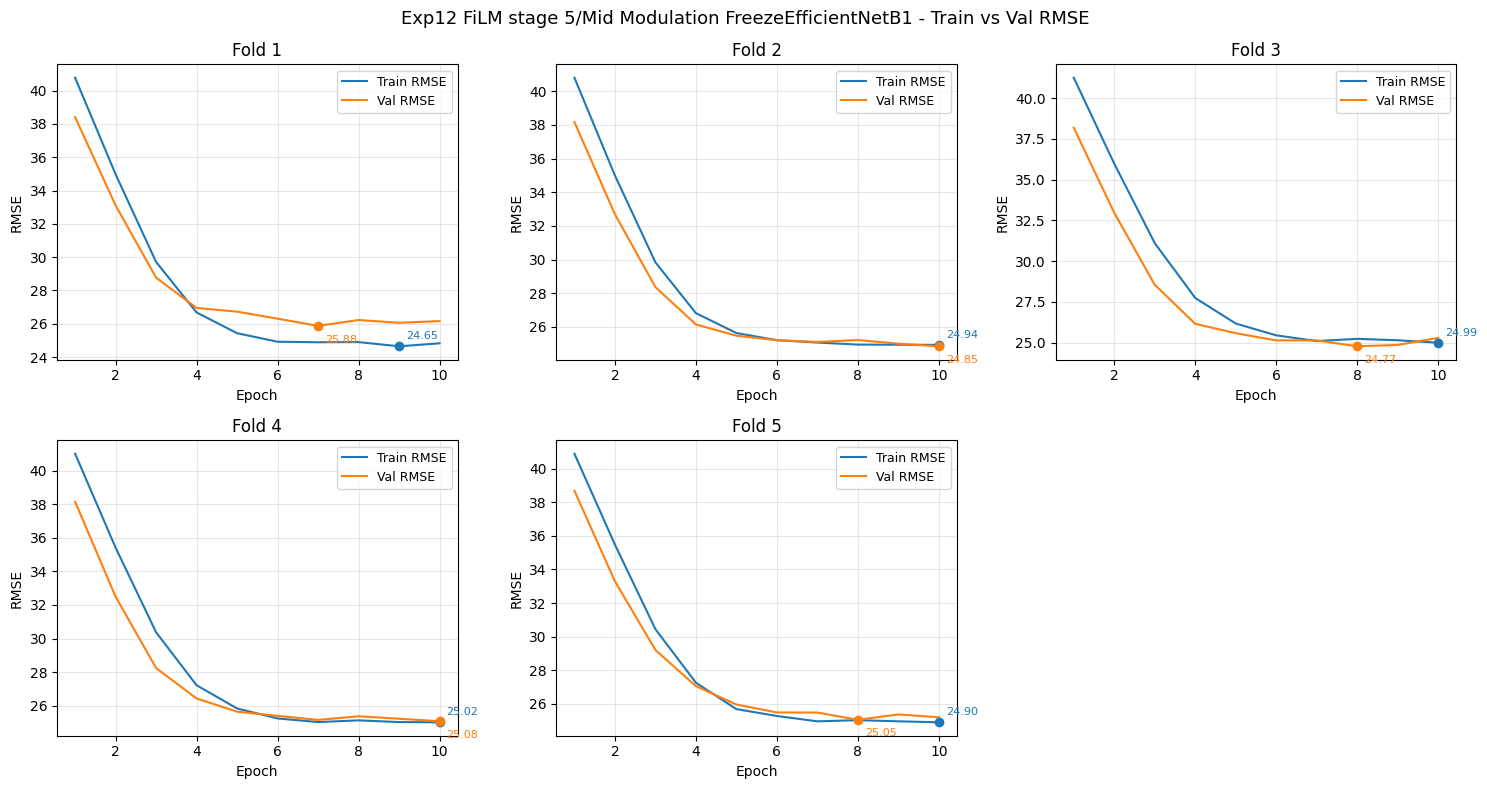

In [6]:
from src.plot import plot_train_val_history
plot_train_val_history(out_dir, folds=[1,2,3,4,5], title_prefix="Exp12 FiLM stage 5/Mid Modulation FreezeEfficientNetB1")

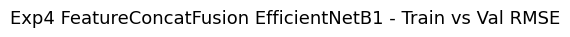

In [7]:
from src.plot import plot_train_val_history
out_dir1 = os.path.join("../..", "outputs", "exp4")
plot_train_val_history(out_dir1, folds=[1,2,3,4,5], title_prefix="Exp4 FeatureConcatFusion EfficientNetB1")

### Side by Side Comparison with Concatenation based Feature Fusion Exp4

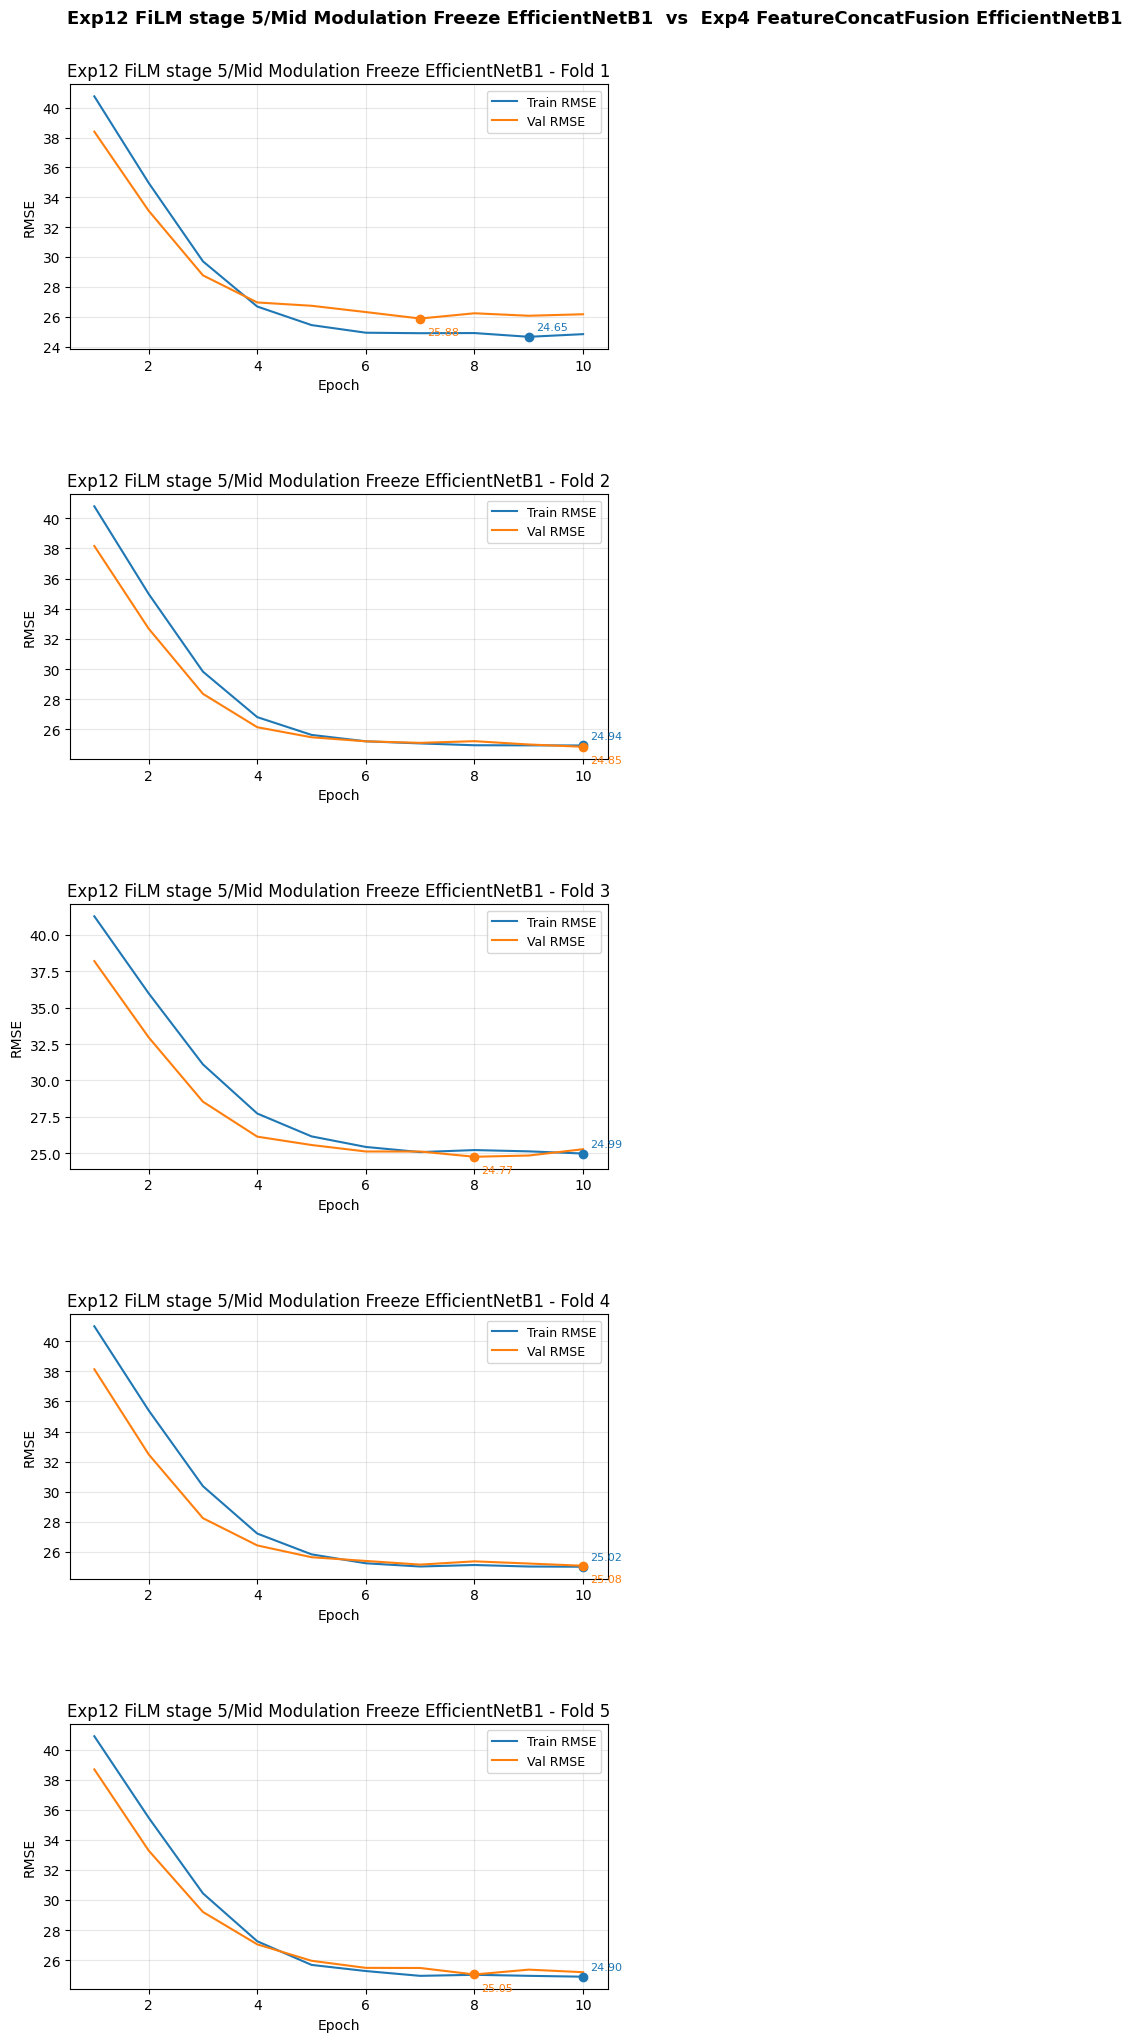

In [8]:
from src.plot import plot_compare_two_experiments
plot_compare_two_experiments(out_dir, out_dir1,folds=[1,2,3,4,5], label_a="Exp12 FiLM stage 5/Mid Modulation Freeze EfficientNetB1", label_b="Exp4 FeatureConcatFusion EfficientNetB1")

In [9]:
#  Inspect worst error rows

errors_path = os.path.join(out_dir, "top50_errors.csv")
err_df = pd.read_csv(errors_path)
err_df.head()

,Id,fold,ytrue,oof_pred,abs_err
0,0067aaaa500b530c76b9c91af34b4cb8,3,98,-0.167409,98.167409
1,1fa822769e0e5e7b5bfc16fe0619af73,4,100,3.755504,96.244496
2,7374d17965f12edf7d2c8bddfad243e6,5,100,4.049465,95.950535
3,fce5c86414b1c60b7af20ddbb8510d83,2,94,-0.199784,94.199784
4,33857326da9557ee620365ef9d61c68f,5,100,6.647202,93.352798


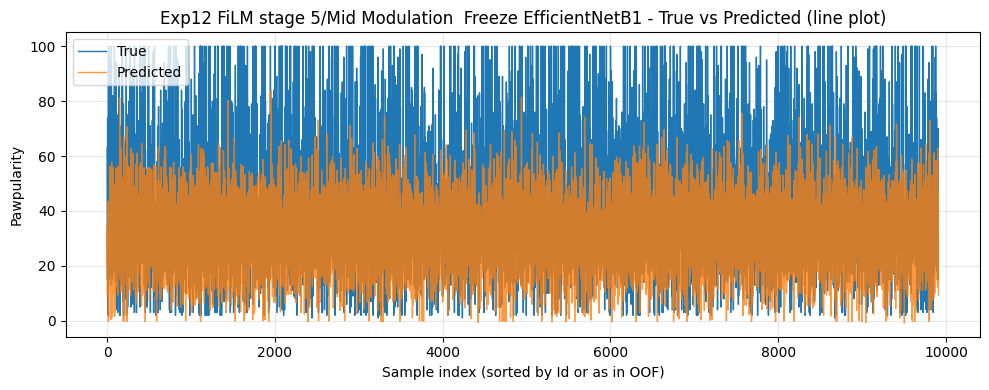

In [10]:
import os
import pandas as pd
from src.plot import (
   plot_oof_true_pred_lines,
    show_images_grid,
)

# Load OOF detail and top-errors
oof_df = pd.read_csv(os.path.join(out_dir, "oof_detail.csv"))
err_df = pd.read_csv(os.path.join(out_dir, "top50_errors.csv"))

# Plot
plot_oof_true_pred_lines(oof_df, title_prefix="Exp12 FiLM stage 5/Mid Modulation  Freeze EfficientNetB1")





In [11]:
from src.plot import compare_oof_by_bins
bins = [0, 20, 40, 60, 80, 100]

df_bins, rmse3_all, rmse5_all, gap = compare_oof_by_bins(
    oof_path_a=os.path.join(out_dir, "oof_detail.csv"),
    oof_path_b=os.path.join(out_dir1, "oof_detail.csv"),
    bins=bins,
    label_a="Exp12 FiLM stage 5/Mid Modulation Freeze EfficientNetB1",
    label_b="Exp4_FeatureConcat EffB1 Fusion",
    title_prefix="EfficientNet",
)

FileNotFoundError: [Errno 2] No such file or directory: '../../outputs/exp4/oof_detail.csv'

In [ ]:
df_bins.head()

,bin,count,Exp12 FiLM stage 5/Mid Modulation Freeze EfficientNetB1_rmse,Exp4_FeatureConcat EffB1 Fusion_rmse,rmse_diff,winner
0,"(0, 20]",1417,22.215062,23.561754,1.346692,Exp12 FiLM stage 5/Mid Modulation Freeze Effic...
1,"(20, 40]",5119,13.624519,11.605182,-2.019337,Exp4_FeatureConcat EffB1 Fusion_better
2,"(40, 60]",2088,22.719435,16.538259,-6.181176,Exp4_FeatureConcat EffB1 Fusion_better
3,"(60, 80]",727,39.883636,30.127592,-9.756043,Exp4_FeatureConcat EffB1 Fusion_better
4,"(80, 100]",561,63.950743,46.623998,-17.326744,Exp4_FeatureConcat EffB1 Fusion_better


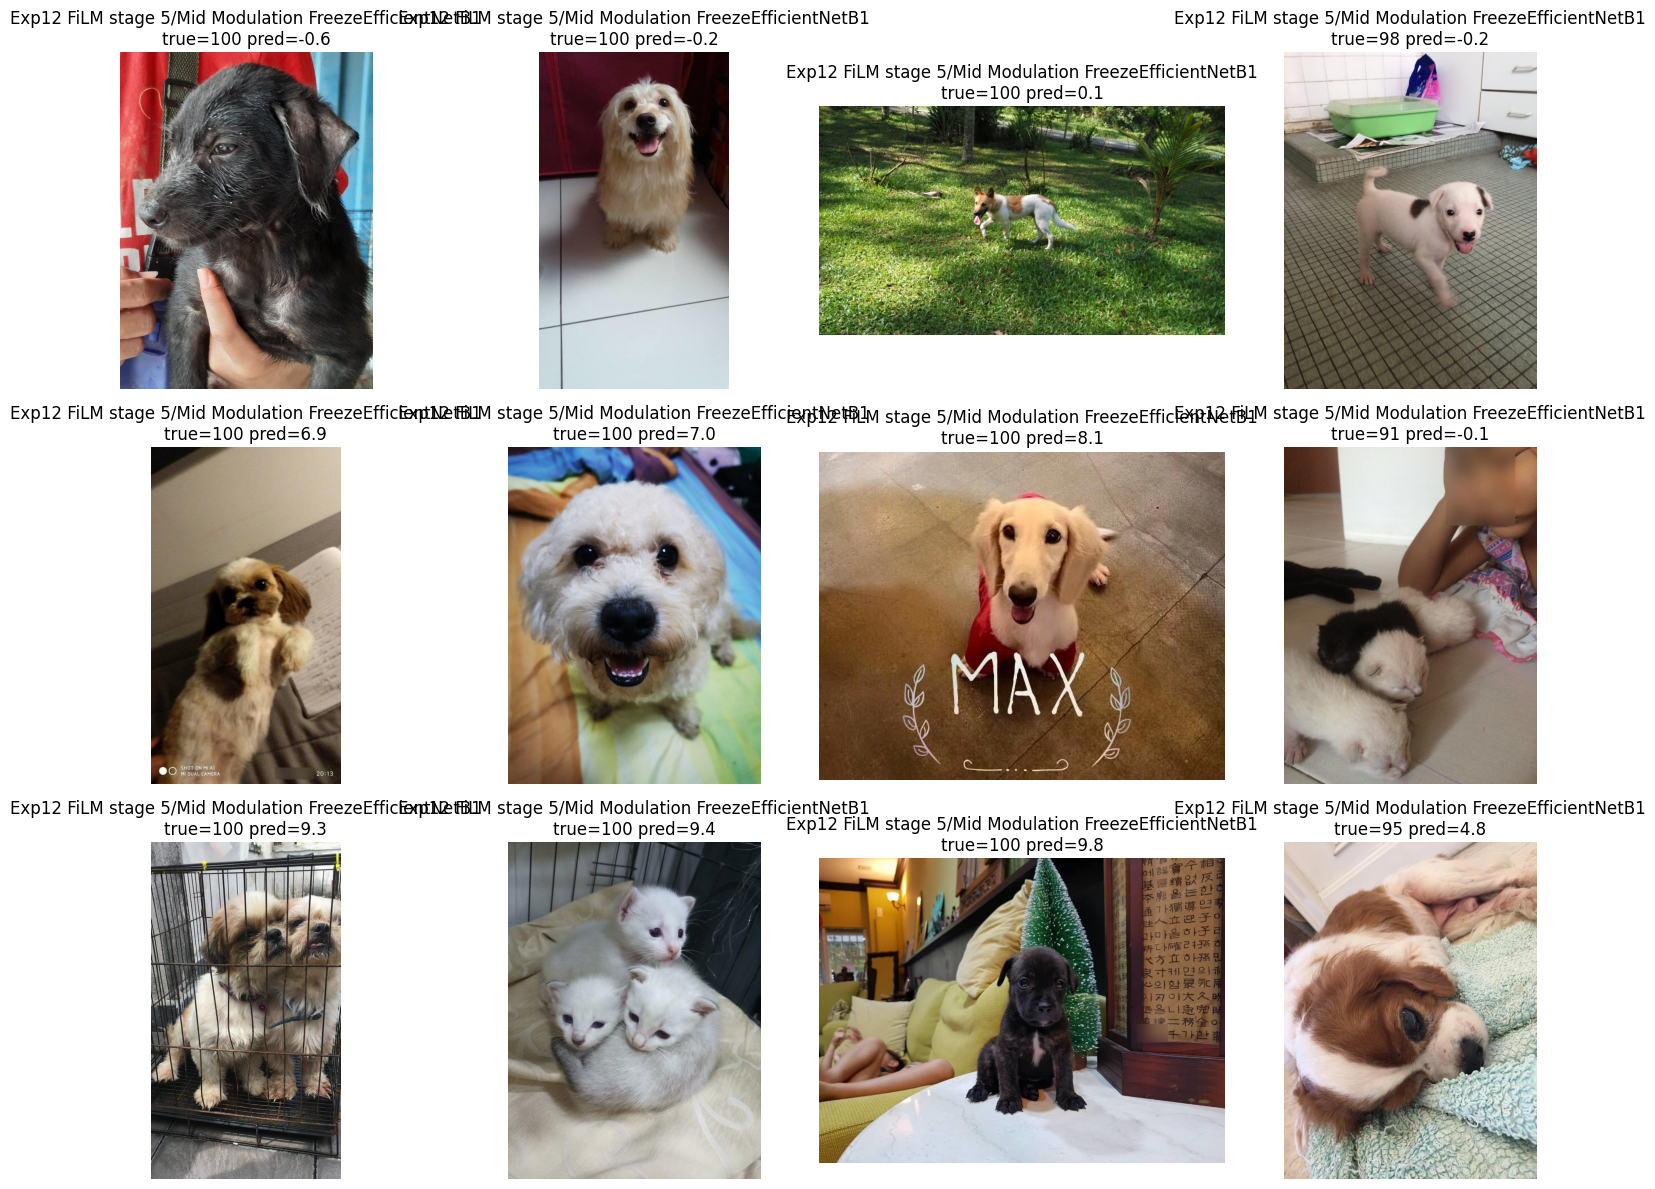

In [ ]:
# Images of worst errors of FiLM 12 experiment
img_folder = os.path.join(main_folder, "data", "train")
show_images_grid(err_df, img_folder, n=12, title_prefix="Exp12 FiLM stage 5/Mid Modulation FreezeEfficientNetB1")

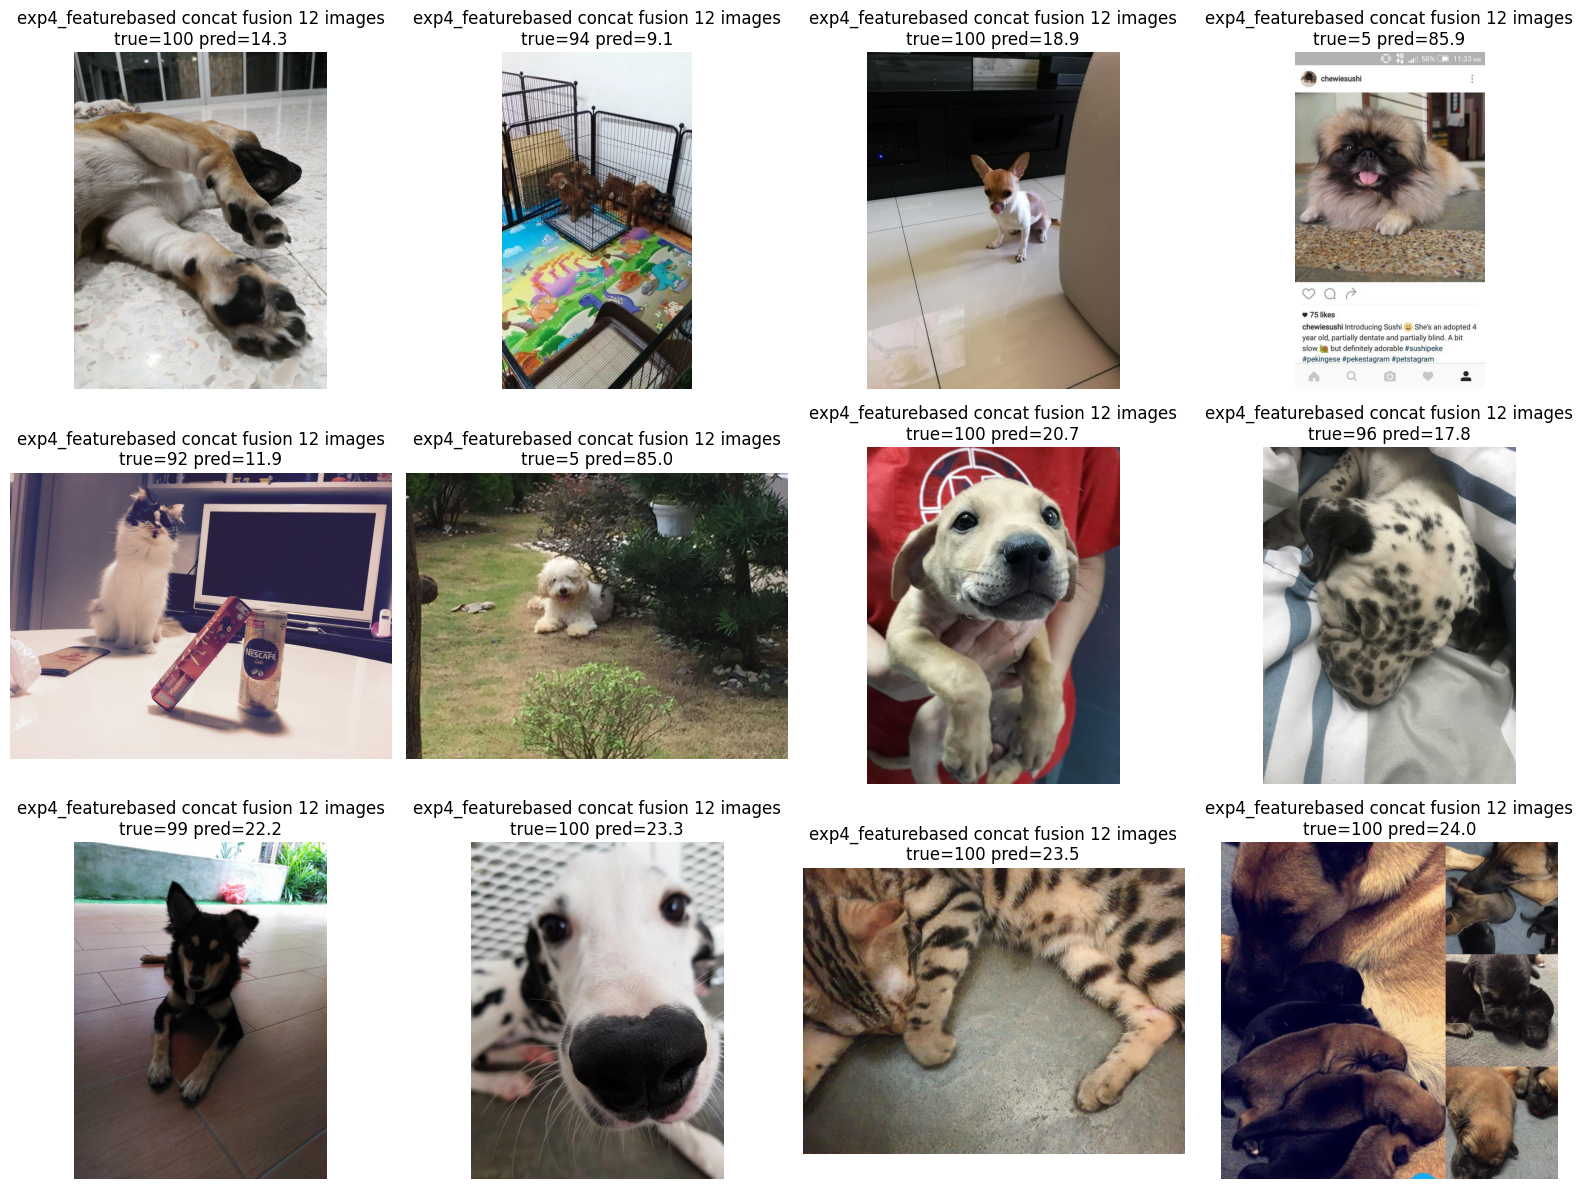

In [ ]:

# Load OOF detail and top-errors of Exp4 
oof_df1 = pd.read_csv(os.path.join(out_dir1, "oof_detail.csv"))
err_df1 = pd.read_csv(os.path.join(out_dir1, "top50_errors.csv"))
show_images_grid(err_df1, img_folder, n=12, title_prefix="exp4_featurebased concat fusion 12 images")